# 🔬 Automated Bladder Cancer Screening, Vision Transformer (ViT)
**Pratik Nileshkumar Gajjar | Masters Project | Cedars-Sinai AI Campus | 2026**

---

### Project Pipeline
1. **Load & Explore Data**, urothelial cell images + ground-truth masks
2. **Baseline Methods**, Intensity Thresholding & K-Means clustering
3. **ViT Segmentation Model**, `vit_base_patch16_224` encoder + UNet-style decoder
4. **Training & Evaluation**, pixel-wise metrics, loss curves, visual results
5. **N/C Ratio Analysis**, predicted vs true ratio (Spearman correlation)
6. **Clinical Validation**, N/C ratio vs patient diagnoses (neg / aty / sus / pos)

**Label convention:** `0` = Background | `1` = Cytoplasm | `2` = Nucleus

## Section 1, Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# ── Core ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pickle, os, random
from pathlib import Path

# ── Vision / ML ───────────────────────────────────────────────
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.cluster import MiniBatchKMeans
from scipy.stats import spearmanr
from scipy.stats import kendalltau

# ── Plotting ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Device ────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── Paths ─────────────────────────────────────────────────────
DATA_DIR  = Path(r"D:\Masters Project")
CELL_PKL  = DATA_DIR / "cell_specimens_data" / "urothelial_cell_toy_data.pkl"
SPEC_PKL  = DATA_DIR / "specimens_toy_data (3).pkl"
MODEL_DIR = DATA_DIR / "saved_models"
MODEL_DIR.mkdir(exist_ok=True)
print(f"\nCell data : {CELL_PKL.exists()}")
print(f"Spec data : {SPEC_PKL.exists()}")

PyTorch  : 2.11.0+cu128
Device   : cuda
GPU      : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM     : 8.6 GB

Cell data : True
Spec data : True


## Section 2, Load & Explore Data

In [2]:
# ── Load urothelial cell data ─────────────────────────────────
with open(CELL_PKL, 'rb') as f:
    raw = pickle.load(f)

images_all = raw['X'].numpy()            # (200, 3, 256, 256)  float32  0-1
labels_all = np.array(raw['y'])          # (200, 256, 256)     int64    0/1/2

# Convert images to (N, H, W, C) uint8 for visualisation / OpenCV
images_hwc = np.transpose((images_all * 255).astype(np.uint8), (0, 2, 3, 1))

# Drop cells with no nucleus label (label==2 never appears)
has_nucleus = (labels_all == 2).sum(axis=(1, 2)) > 0
images_all  = images_all[has_nucleus]
labels_all  = labels_all[has_nucleus]
images_hwc  = images_hwc[has_nucleus]

print("── Dataset Summary ──────────────────────────────")
print(f"  Total usable cells : {len(images_all)}")
print(f"  Image tensor shape : {images_all.shape}  (N, C, H, W)")
print(f"  Label tensor shape : {labels_all.shape}  (N, H, W)")
print(f"  Image value range  : {images_all.min():.2f} – {images_all.max():.2f}")
print()
vals, cnts = np.unique(labels_all, return_counts=True)
labels_map = {0: 'Background', 1: 'Cytoplasm', 2: 'Nucleus'}
print("  Pixel-class distribution:")
total_px = labels_all.size
for v, c in zip(vals, cnts):
    print(f"    Class {v} ({labels_map[v]:12s}): {c:>10,}  ({100*c/total_px:.1f}%)")

── Dataset Summary ──────────────────────────────
  Total usable cells : 191
  Image tensor shape : (191, 3, 256, 256)  (N, C, H, W)
  Label tensor shape : (191, 256, 256)  (N, H, W)
  Image value range  : 0.00 – 1.00

  Pixel-class distribution:
    Class 0 (Background  ):  4,477,770  (35.8%)
    Class 1 (Cytoplasm   ):  5,471,086  (43.7%)
    Class 2 (Nucleus     ):  2,568,520  (20.5%)


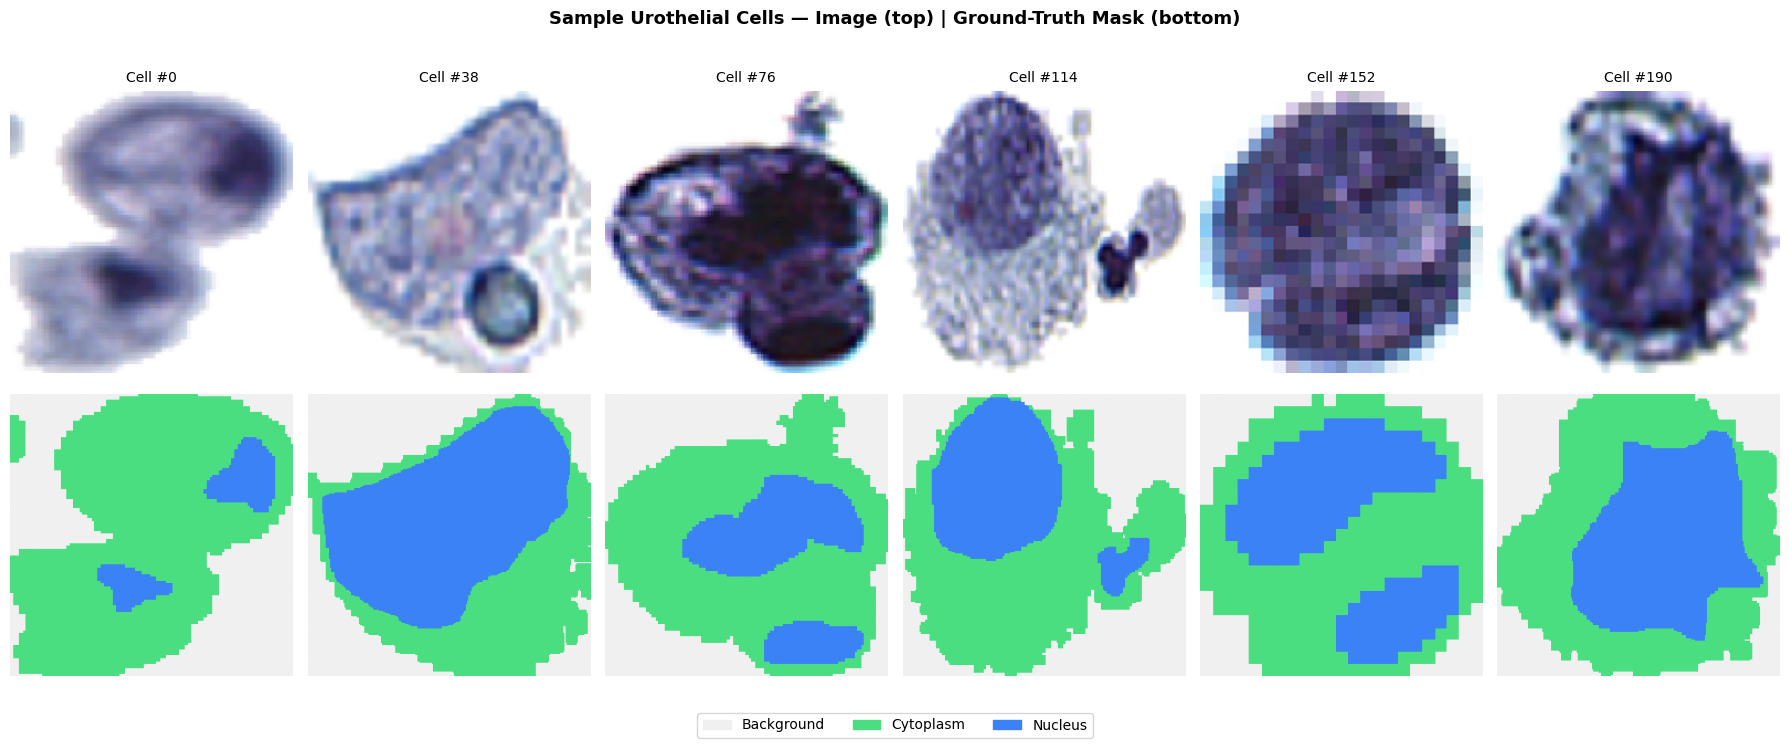

In [3]:
# ── Visualise 6 sample cells with ground-truth masks ─────────
CMAP = plt.matplotlib.colors.ListedColormap(['#f0f0f0', '#4ade80', '#3b82f6'])

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle("Sample Urothelial Cells, Image (top) | Ground-Truth Mask (bottom)",
             fontsize=13, fontweight='bold', y=1.01)

sample_idx = np.linspace(0, len(images_hwc)-1, 6, dtype=int)
for col, idx in enumerate(sample_idx):
    axes[0, col].imshow(images_hwc[idx])
    axes[0, col].set_title(f"Cell #{idx}", fontsize=10)
    axes[0, col].axis('off')

    axes[1, col].imshow(labels_all[idx], cmap=CMAP, vmin=0, vmax=2)
    axes[1, col].axis('off')

patches = [mpatches.Patch(color='#f0f0f0', label='Background'),
           mpatches.Patch(color='#4ade80', label='Cytoplasm'),
           mpatches.Patch(color='#3b82f6', label='Nucleus')]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.show()

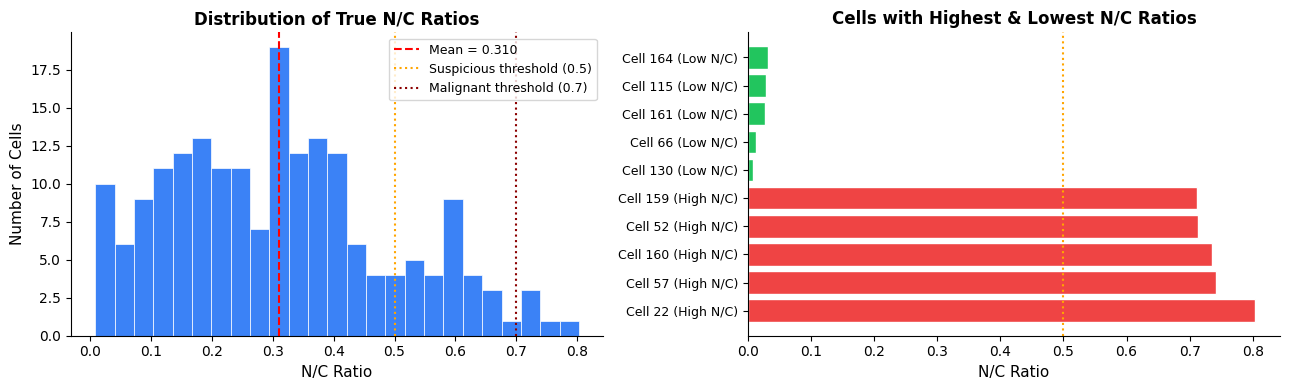

N/C ratio stats: min=0.008  max=0.803  mean=0.310  std=0.182


In [4]:
# ── Compute TRUE N/C ratios for all cells ────────────────────
def compute_nc_ratio(mask):
    """NC ratio = nucleus_pixels / (nucleus + cytoplasm pixels)"""
    nuc  = (mask == 2).sum()
    cyto = (mask == 1).sum()
    return nuc / (nuc + cyto + 1e-8)

nc_ratios_true = np.array([compute_nc_ratio(labels_all[i]) for i in range(len(labels_all))])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(nc_ratios_true, bins=25, color='#3b82f6', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('N/C Ratio', fontsize=11)
axes[0].set_ylabel('Number of Cells', fontsize=11)
axes[0].set_title('Distribution of True N/C Ratios', fontsize=12, fontweight='bold')
axes[0].axvline(nc_ratios_true.mean(), color='red', linestyle='--',
                label=f'Mean = {nc_ratios_true.mean():.3f}')
axes[0].axvline(0.5, color='orange', linestyle=':', label='Suspicious threshold (0.5)')
axes[0].axvline(0.7, color='darkred', linestyle=':', label='Malignant threshold (0.7)')
axes[0].legend(fontsize=9); axes[0].spines[['top','right']].set_visible(False)

# NC ratio overlaid on sample cells
n_show = 5
sample_hi  = np.argsort(nc_ratios_true)[-n_show:][::-1]   # highest NC
sample_lo  = np.argsort(nc_ratios_true)[:n_show]           # lowest NC
show_idx   = np.concatenate([sample_hi, sample_lo])
labels_row = ['High N/C']*n_show + ['Low N/C']*n_show
axes[1].barh(range(len(show_idx)),
             nc_ratios_true[show_idx],
             color=['#ef4444' if l=='High N/C' else '#22c55e' for l in labels_row],
             edgecolor='white')
axes[1].set_yticks(range(len(show_idx)))
axes[1].set_yticklabels([f"Cell {i} ({l})" for i, l in zip(show_idx, labels_row)], fontsize=9)
axes[1].set_xlabel('N/C Ratio', fontsize=11)
axes[1].set_title('Cells with Highest & Lowest N/C Ratios', fontsize=12, fontweight='bold')
axes[1].axvline(0.5, color='orange', linestyle=':', linewidth=1.5)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()
print(f"N/C ratio stats: min={nc_ratios_true.min():.3f}  max={nc_ratios_true.max():.3f}  "
      f"mean={nc_ratios_true.mean():.3f}  std={nc_ratios_true.std():.3f}")

In [5]:
# ── Train / Val / Test split  (80 / 10 / 10) ─────────────────
# Stratify by NC-ratio quartile so all splits have similar difficulty
nc_quartile = pd.qcut(nc_ratios_true, q=4, labels=False)

idx_all = np.arange(len(images_all))
idx_tv, idx_test = train_test_split(idx_all, test_size=0.10,
                                     stratify=nc_quartile, random_state=SEED)
nc_quartile_tv = nc_quartile[idx_tv]
idx_train, idx_val = train_test_split(idx_tv, test_size=0.111,   # 0.111 of 90% ≈ 10%
                                       stratify=nc_quartile_tv, random_state=SEED)

print(f"Train : {len(idx_train)} cells")
print(f"Val   : {len(idx_val)} cells")
print(f"Test  : {len(idx_test)} cells")
print(f"Total : {len(idx_train)+len(idx_val)+len(idx_test)} cells")

Train : 152 cells
Val   : 19 cells
Test  : 20 cells
Total : 191 cells


## Section 3, Baseline Methods

### 3a, Intensity Thresholding
Uses pixel brightness to separate nucleus (darkest), cytoplasm (mid), and background (brightest). Simple and fast, no learning required.

── Intensity Thresholding, Test Set ────────────────────
              precision    recall  f1-score   support

  Background      0.667     0.994     0.799    448123
   Cytoplasm      0.885     0.513     0.650    591781
     Nucleus      0.772     0.854     0.811    270816

    accuracy                          0.748   1310720
   macro avg      0.775     0.787     0.753   1310720
weighted avg      0.787     0.748     0.734   1310720



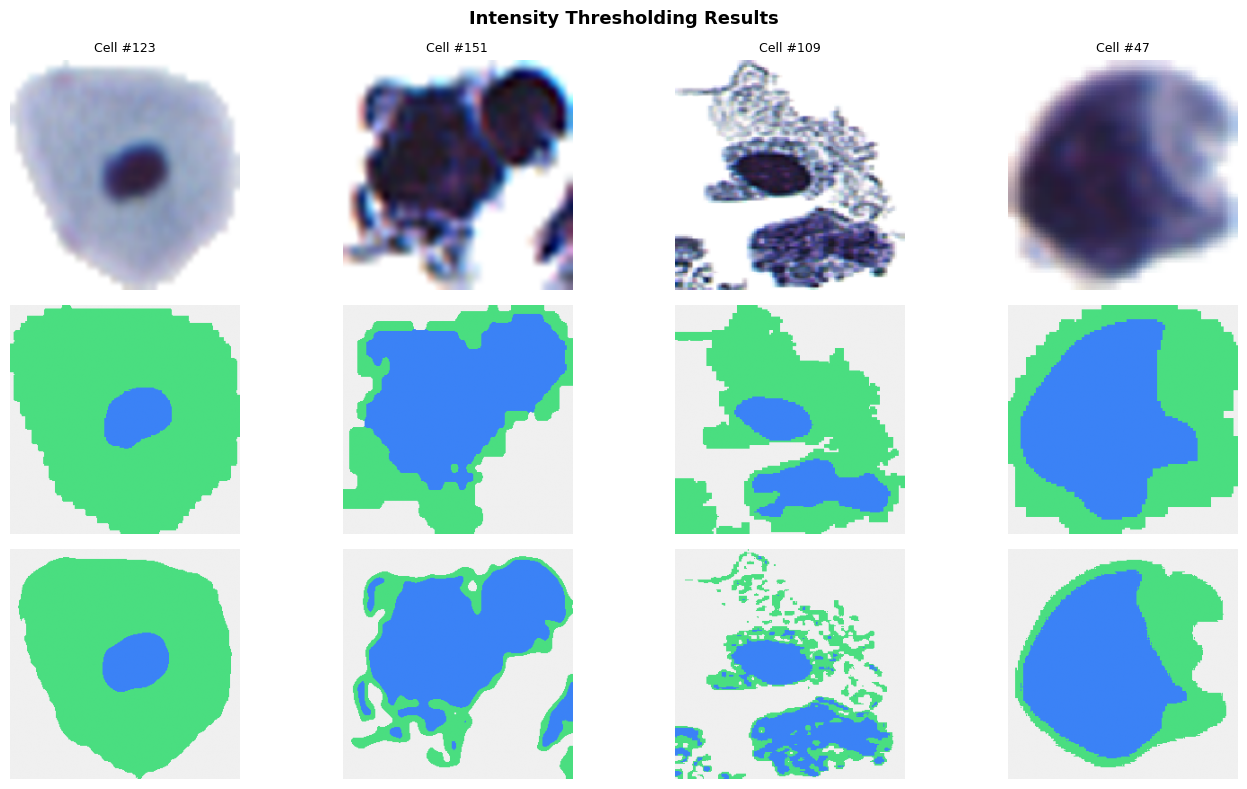

In [6]:
def intensity_threshold_segment(img_hwc):
    """
    Segment a single cell image using Otsu's intensity thresholding.
    Returns mask: 0=BG, 1=Cytoplasm, 2=Nucleus
    """
    gray = cv2.cvtColor(img_hwc, cv2.COLOR_RGB2GRAY)
    # Otsu threshold 1: separate cell (dark) from background (bright)
    _, bg_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # Otsu threshold 2 (on cell region only): separate nucleus from cytoplasm
    cell_pixels = gray[bg_mask > 0]
    if len(cell_pixels) == 0:
        return np.zeros(gray.shape, dtype=np.int64)
    thresh2, _ = cv2.threshold(cell_pixels.reshape(-1,1), 0, 255,
                                cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask = np.zeros(gray.shape, dtype=np.int64)
    mask[bg_mask > 0] = 1                      # cytoplasm
    mask[(bg_mask > 0) & (gray < thresh2)] = 2 # nucleus (darker within cell)
    return mask

# Run on test set
thresh_preds = np.array([intensity_threshold_segment(images_hwc[i]) for i in idx_test])

# Metrics
y_true_flat = labels_all[idx_test].flatten()
y_thresh_flat = thresh_preds.flatten()
print("── Intensity Thresholding, Test Set ────────────────────")
print(classification_report(y_true_flat, y_thresh_flat,
                            target_names=['Background','Cytoplasm','Nucleus'],
                            digits=3))

# Visualise 4 examples
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
fig.suptitle("Intensity Thresholding Results", fontsize=13, fontweight='bold')
titles = ['Original', 'Ground Truth', 'Predicted']
for col, idx in enumerate(idx_test[:4]):
    axes[0,col].imshow(images_hwc[idx]); axes[0,col].set_title(f'Cell #{idx}',fontsize=9); axes[0,col].axis('off')
    axes[1,col].imshow(labels_all[idx], cmap=CMAP, vmin=0, vmax=2); axes[1,col].axis('off')
    axes[2,col].imshow(intensity_threshold_segment(images_hwc[idx]), cmap=CMAP, vmin=0, vmax=2); axes[2,col].axis('off')
for row, t in enumerate(['Image','Ground Truth','Threshold Pred']):
    axes[row,0].set_ylabel(t, fontsize=10)
plt.tight_layout(); plt.show()

### 3b, K-Means Clustering
Groups pixels into 3 clusters by colour similarity. No intensity assumption, learns cluster centres from data.

── K-Means Clustering, Test Set ───────────────────────
              precision    recall  f1-score   support

  Background      0.797     0.990     0.883    448123
   Cytoplasm      0.939     0.651     0.769    591781
     Nucleus      0.724     0.917     0.809    270816

    accuracy                          0.822   1310720
   macro avg      0.820     0.853     0.820   1310720
weighted avg      0.846     0.822     0.816   1310720



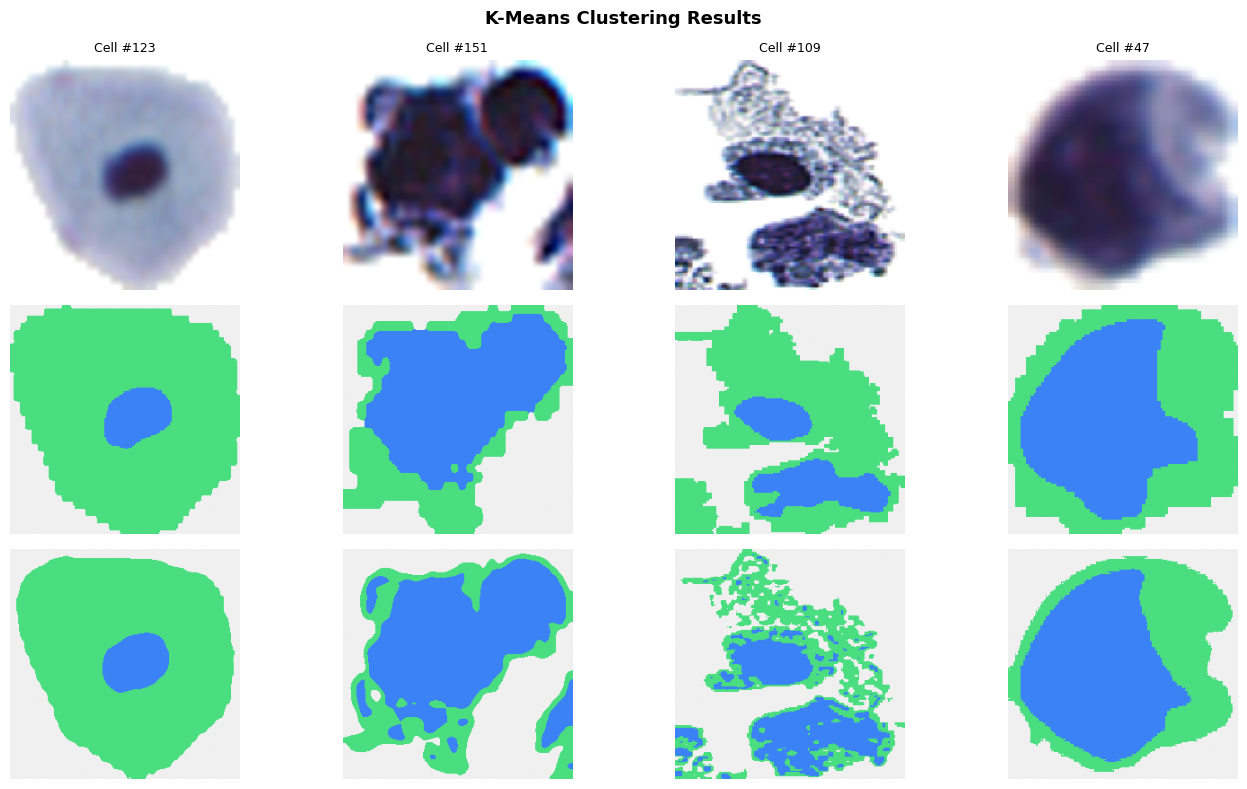

In [7]:
def kmeans_segment(img_hwc, n_clusters=3):
    """
    Segment using K-Means on RGB pixels.
    Clusters are reordered by mean brightness → 0=BG(bright), 1=Cyto(mid), 2=Nuc(dark).
    """
    H, W = img_hwc.shape[:2]
    pixels = img_hwc.reshape(-1, 3).astype(np.float32)
    km = MiniBatchKMeans(n_clusters=n_clusters, random_state=SEED, n_init=3)
    cluster_ids = km.fit_predict(pixels)
    # Sort clusters by brightness (mean intensity of centre)
    centers = km.cluster_centers_
    brightness = centers.mean(axis=1)
    order = np.argsort(brightness)[::-1]   # bright → dark
    remap = {order[0]: 0, order[1]: 1, order[2]: 2}
    mask = np.vectorize(remap.get)(cluster_ids).reshape(H, W).astype(np.int64)
    return mask

# Run on test set
kmeans_preds = np.array([kmeans_segment(images_hwc[i]) for i in idx_test])

print("── K-Means Clustering, Test Set ───────────────────────")
print(classification_report(y_true_flat, kmeans_preds.flatten(),
                            target_names=['Background','Cytoplasm','Nucleus'],
                            digits=3))

# Visualise
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
fig.suptitle("K-Means Clustering Results", fontsize=13, fontweight='bold')
for col, idx in enumerate(idx_test[:4]):
    axes[0,col].imshow(images_hwc[idx]); axes[0,col].set_title(f'Cell #{idx}',fontsize=9); axes[0,col].axis('off')
    axes[1,col].imshow(labels_all[idx], cmap=CMAP, vmin=0, vmax=2); axes[1,col].axis('off')
    axes[2,col].imshow(kmeans_segment(images_hwc[idx]), cmap=CMAP, vmin=0, vmax=2); axes[2,col].axis('off')
for row, t in enumerate(['Image','Ground Truth','K-Means Pred']):
    axes[row,0].set_ylabel(t, fontsize=10)
plt.tight_layout(); plt.show()

## Section 4, Vision Transformer (ViT) Segmentation Model

### Architecture
```
Input Image (B, 3, 256, 256)
        │
   ┌────▼─────────────────────────────────────────────┐
   │  ViT Encoder  (vit_base_patch16_224, timm)      │
   │  • Splits image into 16×16 patches → 256 tokens  │
   │  • Linear projection → 768-dim embeddings        │
   │  • + Positional encoding                         │
   │  • 12× Transformer blocks (Multi-Head Attention) │
   │  Output: (B, 257, 768)  [CLS + 256 patches]      │
   └────┬─────────────────────────────────────────────┘
        │  Remove CLS → reshape
   (B, 768, 16, 16) , spatial feature map
        │
   ┌────▼──────────────────────────────────────────┐
   │  UNet-style Decoder (4× ConvTranspose blocks) │
   │  16→32→64→128→256                             │
   │  Output: (B, 3, 256, 256)                     │
   └────┬──────────────────────────────────────────┘
        │
   Softmax → class probabilities per pixel
   (0=BG, 1=Cytoplasm, 2=Nucleus)
```

In [8]:
class DecoderBlock(nn.Module):
    """Single upsampling block: ConvTranspose2d → BN → ReLU → Conv → BN → ReLU"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class ViTSegmentation(nn.Module):
    """
    Vision Transformer encoder + UNet-style decoder for 3-class cell segmentation.

    Encoder : timm vit_base_patch16_224 (pretrained on ImageNet-21k)
              → patch tokens reshaped to (B, 768, 16, 16)
    Decoder : 4 upsampling blocks  16→32→64→128→256
    Head    : 1×1 Conv → 3 classes (BG / Cytoplasm / Nucleus)
    """
    def __init__(self, num_classes=3, img_size=256, pretrained=True):
        super().__init__()
        self.patch_size = 16
        self.grid       = img_size // self.patch_size   # 16
        embed_dim       = 768

        # ── ViT encoder ──────────────────────────────────────
        self.encoder = timm.create_model(
            'vit_base_patch16_224',
            pretrained=pretrained,
            img_size=img_size,
            num_classes=0,      # remove classification head
            global_pool=''      # keep all token outputs
        )

        # ── UNet-style decoder ────────────────────────────────
        # 16×16 → 32×32 → 64×64 → 128×128 → 256×256
        self.decoder = nn.Sequential(
            DecoderBlock(embed_dim, 256),   # 16  → 32
            DecoderBlock(256,       128),   # 32  → 64
            DecoderBlock(128,        64),   # 64  → 128
            DecoderBlock( 64,        32),   # 128 → 256
        )

        # ── Segmentation head ─────────────────────────────────
        self.head = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        # x: (B, 3, H, W)
        tokens = self.encoder.forward_features(x)       # (B, 257, 768)
        patch_tokens = tokens[:, 1:, :]                 # drop CLS: (B, 256, 768)
        B, N, D = patch_tokens.shape
        # reshape to spatial feature map
        spatial = patch_tokens.transpose(1, 2).reshape(B, D, self.grid, self.grid)
        # decode
        out = self.decoder(spatial)                     # (B, 32, 256, 256)
        return self.head(out)                           # (B, 3, 256, 256)


# ── Quick sanity check ────────────────────────────────────────
model = ViTSegmentation(num_classes=3, img_size=256, pretrained=False)
dummy = torch.zeros(2, 3, 256, 256)
with torch.no_grad():
    out = model(dummy)
print(f"Input  shape : {dummy.shape}")
print(f"Output shape : {out.shape}  ← (B, 3-classes, H, W)  ✓")
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params : {total_params/1e6:.1f} M")
print(f"Trainable    : {trainable/1e6:.1f} M")

Input  shape : torch.Size([2, 3, 256, 256])
Output shape : torch.Size([2, 3, 256, 256])  ← (B, 3-classes, H, W)  ✓
Total params : 87.6 M
Trainable    : 87.6 M


## Section 5, Dataset, Augmentation & Training

In [9]:
import torchvision.transforms.functional as TF

class CellDataset(Dataset):
    """
    PyTorch Dataset for urothelial cell images.
    Augmentation (train only): random horizontal/vertical flip + 90° rotation.
    Images are already float32 [0,1] in (C,H,W) format.
    """
    def __init__(self, images, labels, augment=False):
        self.images  = torch.FloatTensor(images)   # (N, 3, 256, 256)
        self.labels  = torch.LongTensor(labels)    # (N, 256, 256)
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]    # (3, H, W)
        lbl = self.labels[idx]    # (H, W)

        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                img = TF.hflip(img)
                lbl = TF.hflip(lbl.unsqueeze(0)).squeeze(0)
            # Random vertical flip
            if random.random() > 0.5:
                img = TF.vflip(img)
                lbl = TF.vflip(lbl.unsqueeze(0)).squeeze(0)
            # Random 90° rotation
            k = random.randint(0, 3)
            if k > 0:
                img = torch.rot90(img, k, [1, 2])
                lbl = torch.rot90(lbl, k, [0, 1])
        return img, lbl


# ── DataLoaders ───────────────────────────────────────────────
BATCH_SIZE = 4   # safe for 8GB VRAM with ViT-Base

train_ds = CellDataset(images_all[idx_train], labels_all[idx_train], augment=True)
val_ds   = CellDataset(images_all[idx_val],   labels_all[idx_val],   augment=False)
test_ds  = CellDataset(images_all[idx_test],  labels_all[idx_test],  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches : {len(train_loader)}  ({len(train_ds)} images)")
print(f"Val batches   : {len(val_loader)}  ({len(val_ds)} images)")
print(f"Test batches  : {len(test_loader)}  ({len(test_ds)} images)")

# Show one batch
imgs_b, lbls_b = next(iter(train_loader))
print(f"\nBatch images  : {imgs_b.shape}  dtype={imgs_b.dtype}")
print(f"Batch labels  : {lbls_b.shape}  dtype={lbls_b.dtype}")

Train batches : 38  (152 images)
Val batches   : 5  (19 images)
Test batches  : 5  (20 images)

Batch images  : torch.Size([4, 3, 256, 256])  dtype=torch.float32
Batch labels  : torch.Size([4, 256, 256])  dtype=torch.int64


In [10]:
# ── Build model with pretrained ViT encoder ───────────────────
print("Loading pretrained vit_base_patch16_224 (ImageNet-21k)...")
print("(~330 MB download on first run, cached after that)\n")

model = ViTSegmentation(num_classes=3, img_size=256, pretrained=True).to(DEVICE)

# ── Class weights (inverse frequency to handle imbalance) ─────
px_counts = np.bincount(labels_all.flatten(), minlength=3).astype(float)
class_weights = torch.FloatTensor(1.0 / (px_counts / px_counts.sum())).to(DEVICE)
class_weights = class_weights / class_weights.sum() * 3   # normalise

# ── Loss, optimiser, scheduler ────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Two-stage learning rates: lower LR for pretrained encoder, higher for decoder
encoder_params = list(model.encoder.parameters())
decoder_params = list(model.decoder.parameters()) + list(model.head.parameters())

optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': 1e-5},   # fine-tune ViT
    {'params': decoder_params, 'lr': 1e-4},   # train decoder from scratch
], weight_decay=1e-4)

N_EPOCHS   = 40
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-6)

print(f"Criterion : CrossEntropyLoss (class weights: {class_weights.cpu().numpy().round(3)})")
print(f"Optimiser : AdamW  (encoder lr=1e-5, decoder lr=1e-4)")
print(f"Scheduler : CosineAnnealingLR  (T_max={N_EPOCHS})")
print(f"Epochs    : {N_EPOCHS}")
print(f"Device    : {DEVICE}")

Loading pretrained vit_base_patch16_224 (ImageNet-21k)...
(~330 MB download on first run, cached after that)

Criterion : CrossEntropyLoss (class weights: [0.842 0.689 1.468])
Optimiser : AdamW  (encoder lr=1e-5, decoder lr=1e-4)
Scheduler : CosineAnnealingLR  (T_max=40)
Epochs    : 40
Device    : cuda


In [11]:
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    """One train or eval epoch. Returns (loss, pixel_accuracy)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total_px = 0.0, 0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            logits = model(imgs)                        # (B, 3, H, W)
            loss   = criterion(logits, lbls)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds   = logits.argmax(dim=1)
            correct += (preds == lbls).sum().item()
            total_px += lbls.numel()

    return total_loss / len(loader.dataset), correct / total_px


# ── Training loop ─────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
MODEL_PATH = MODEL_DIR / 'vit_seg_best.pth'

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Val Loss':>9}  {'Train Acc':>10}  {'Val Acc':>9}  {'LR':>9}")
print("─" * 65)

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    lr_now = optimizer.param_groups[1]['lr']
    marker = ' ← best' if vl_loss < best_val_loss else ''
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), MODEL_PATH)

    print(f"{epoch:>6}  {tr_loss:>10.4f}  {vl_loss:>9.4f}  "
          f"{tr_acc:>10.4f}  {vl_acc:>9.4f}  {lr_now:>9.2e}{marker}")

print(f"\n✓ Best model saved → {MODEL_PATH}")
print(f"  Best val loss : {best_val_loss:.4f}")

 Epoch  Train Loss   Val Loss   Train Acc    Val Acc         LR
─────────────────────────────────────────────────────────────────
     1      0.7968     0.7416      0.6111     0.7628   9.98e-05 ← best
     2      0.5688     0.4842      0.8274     0.8317   9.94e-05 ← best
     3      0.4576     0.4534      0.8771     0.8927   9.86e-05 ← best
     4      0.4158     0.4127      0.8856     0.8923   9.76e-05 ← best
     5      0.3788     0.3526      0.8988     0.8881   9.62e-05 ← best
     6      0.3539     0.3689      0.9030     0.8728   9.46e-05
     7      0.3317     0.3253      0.9092     0.9118   9.27e-05 ← best
     8      0.3071     0.3086      0.9149     0.9088   9.05e-05 ← best
     9      0.2916     0.3063      0.9218     0.8943   8.81e-05 ← best
    10      0.2725     0.2975      0.9247     0.8980   8.55e-05 ← best
    11      0.2601     0.2790      0.9281     0.9134   8.26e-05 ← best
    12      0.2547     0.2767      0.9286     0.9137   7.96e-05 ← best
    13      0.2359     0.

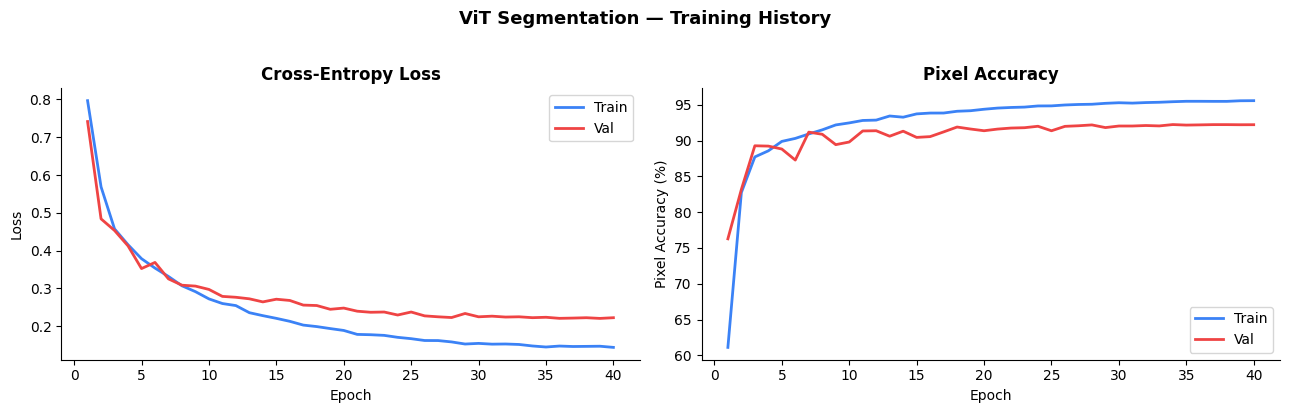

In [12]:
# ── Plot training curves ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_x = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_x, history['train_loss'], label='Train', color='#3b82f6', linewidth=2)
axes[0].plot(epochs_x, history['val_loss'],   label='Val',   color='#ef4444', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Cross-Entropy Loss', fontweight='bold')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(epochs_x, [a*100 for a in history['train_acc']], label='Train', color='#3b82f6', linewidth=2)
axes[1].plot(epochs_x, [a*100 for a in history['val_acc']],   label='Val',   color='#ef4444', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Pixel Accuracy (%)')
axes[1].set_title('Pixel Accuracy', fontweight='bold')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('ViT Segmentation, Training History', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## Section 6, Evaluation on Test Set

In [13]:
# ── Load best checkpoint & predict on test set ───────────────
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()

vit_preds_list, true_list = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        logits = model(imgs.to(DEVICE))
        preds  = logits.argmax(dim=1).cpu().numpy()
        vit_preds_list.append(preds)
        true_list.append(lbls.numpy())

vit_preds = np.concatenate(vit_preds_list, axis=0)   # (N_test, 256, 256)
y_test_np = np.concatenate(true_list, axis=0)

print("── ViT Segmentation, Test Set ──────────────────────────")
print(classification_report(y_test_np.flatten(), vit_preds.flatten(),
                            target_names=['Background','Cytoplasm','Nucleus'],
                            digits=3))

── ViT Segmentation, Test Set ──────────────────────────
              precision    recall  f1-score   support

  Background      0.969     0.951     0.960    448123
   Cytoplasm      0.924     0.919     0.922    591781
     Nucleus      0.877     0.915     0.896    270816

    accuracy                          0.929   1310720
   macro avg      0.924     0.929     0.926   1310720
weighted avg      0.930     0.929     0.930   1310720



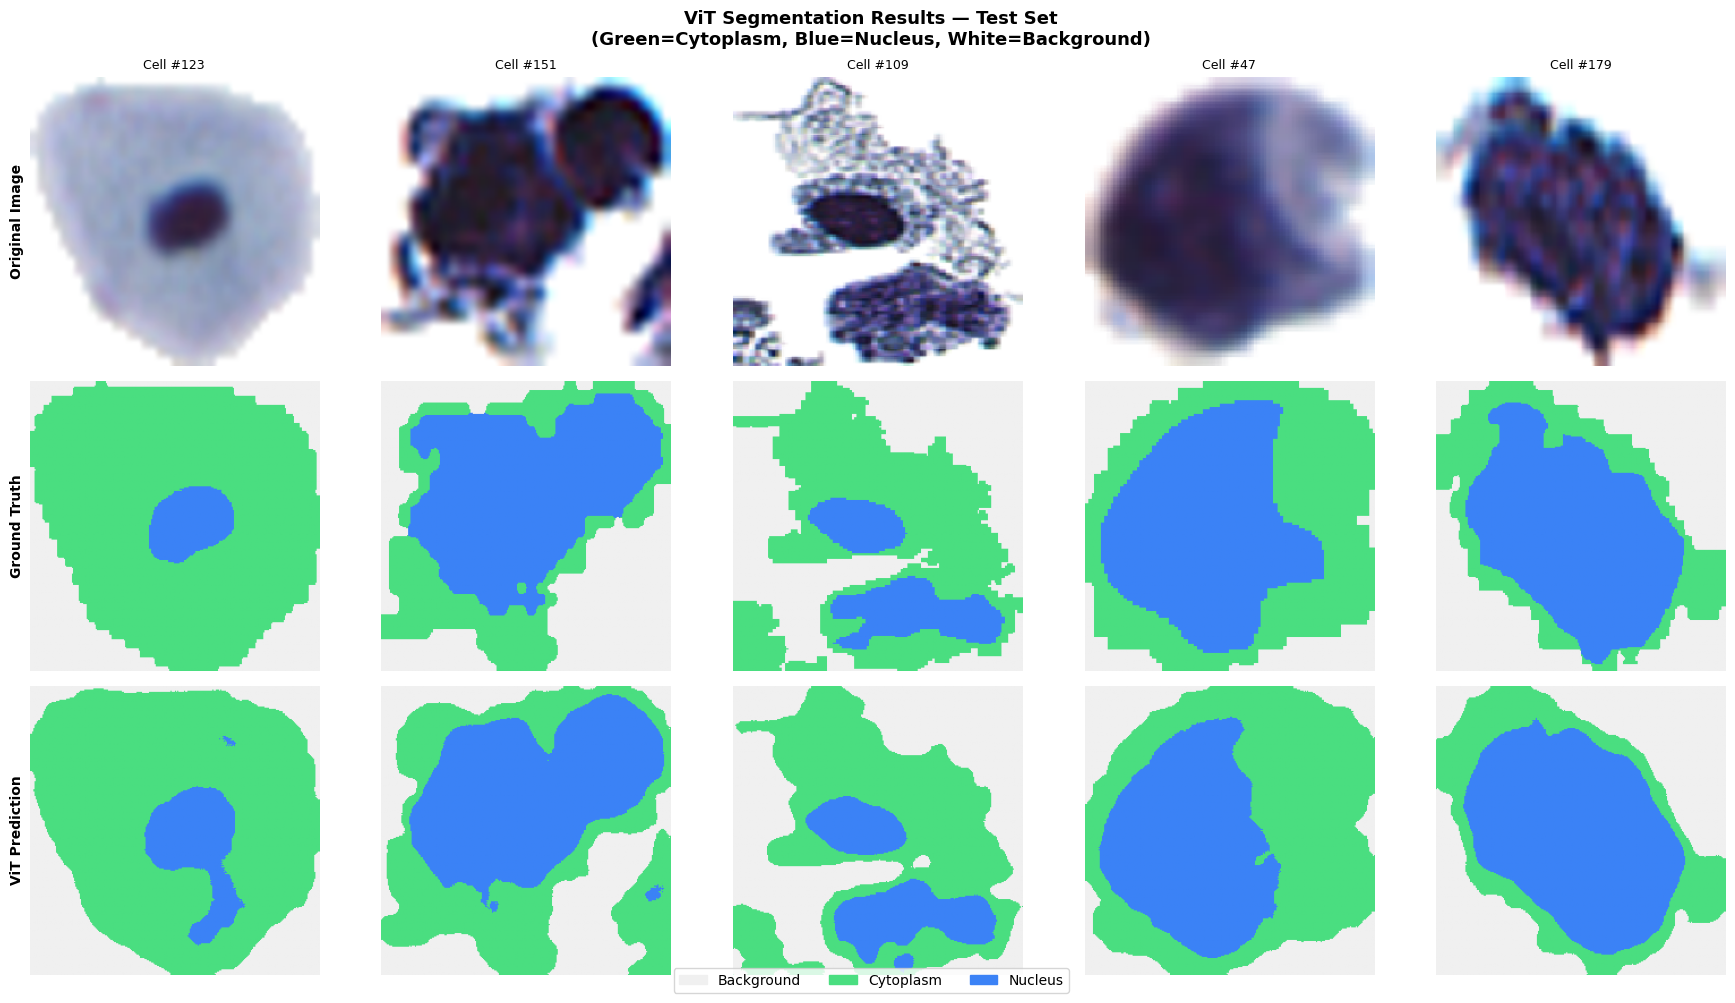

In [14]:
# ── Visual results: Image / Ground Truth / ViT Prediction ─────
n_show = 5
test_imgs_hwc = images_hwc[idx_test]

fig, axes = plt.subplots(3, n_show, figsize=(18, 10))
fig.suptitle("ViT Segmentation Results, Test Set\n(Green=Cytoplasm, Blue=Nucleus, White=Background)",
             fontsize=13, fontweight='bold')

row_labels = ['Original Image', 'Ground Truth', 'ViT Prediction']
for col in range(n_show):
    axes[0, col].imshow(test_imgs_hwc[col])
    axes[0, col].set_title(f"Cell #{idx_test[col]}", fontsize=9)
    axes[1, col].imshow(y_test_np[col],  cmap=CMAP, vmin=0, vmax=2)
    axes[2, col].imshow(vit_preds[col],  cmap=CMAP, vmin=0, vmax=2)
    for row in range(3):
        axes[row, col].axis('off')

for row, lbl in enumerate(row_labels):
    axes[row, 0].set_ylabel(lbl, fontsize=10, fontweight='bold')
    axes[row, 0].axis('on')
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    for sp in axes[row, 0].spines.values(): sp.set_visible(False)

patches = [mpatches.Patch(color='#f0f0f0', label='Background'),
           mpatches.Patch(color='#4ade80', label='Cytoplasm'),
           mpatches.Patch(color='#3b82f6', label='Nucleus')]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5,-0.01))
plt.tight_layout(); plt.show()

## Section 7, N/C Ratio Analysis

**Formula:** `N/C Ratio = Nucleus pixels / (Nucleus + Cytoplasm pixels)`

We compare the **predicted** N/C ratio from ViT segmentation against the **true** ratio from ground-truth masks using Spearman correlation and mean absolute error.

── N/C Ratio Accuracy, Test Set ───────────────────────
Method                   Spearman r     p-value       MAE
─────────────────────────────────────────────────────────
Intensity Threshold          0.7068      0.0005    0.1751
K-Means                      0.7684      0.0001    0.1442
ViT (ours)                   0.9624      0.0000    0.0396


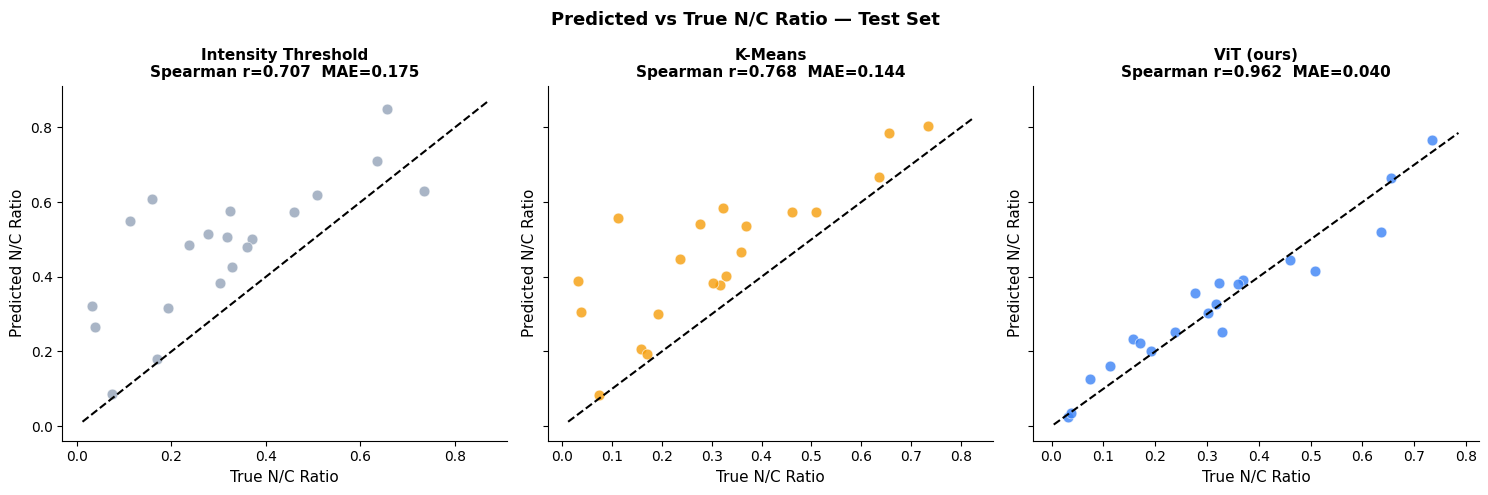

In [15]:
def batch_nc_ratio(masks):
    """Compute N/C ratio for each mask in array (N, H, W)."""
    nuc  = (masks == 2).sum(axis=(1,2))
    cyto = (masks == 1).sum(axis=(1,2))
    return nuc / (nuc + cyto + 1e-8)

# ── Test set: true vs predicted ───────────────────────────────
nc_test_true = batch_nc_ratio(y_test_np)
nc_test_vit  = batch_nc_ratio(vit_preds)
nc_test_thr  = batch_nc_ratio(thresh_preds)
nc_test_km   = batch_nc_ratio(kmeans_preds)

r_vit,  p_vit  = spearmanr(nc_test_vit,  nc_test_true)
r_thr,  p_thr  = spearmanr(nc_test_thr,  nc_test_true)
r_km,   p_km   = spearmanr(nc_test_km,   nc_test_true)

mae_vit = np.abs(nc_test_vit - nc_test_true).mean()
mae_thr = np.abs(nc_test_thr - nc_test_true).mean()
mae_km  = np.abs(nc_test_km  - nc_test_true).mean()

print("── N/C Ratio Accuracy, Test Set ───────────────────────")
print(f"{'Method':<22}  {'Spearman r':>11}  {'p-value':>10}  {'MAE':>8}")
print("─" * 57)
print(f"{'Intensity Threshold':<22}  {r_thr:>11.4f}  {p_thr:>10.4f}  {mae_thr:>8.4f}")
print(f"{'K-Means':<22}  {r_km:>11.4f}  {p_km:>10.4f}  {mae_km:>8.4f}")
print(f"{'ViT (ours)':<22}  {r_vit:>11.4f}  {p_vit:>10.4f}  {mae_vit:>8.4f}")

# ── Scatter plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("Predicted vs True N/C Ratio, Test Set", fontsize=13, fontweight='bold')

for ax, pred, title, r, mae, color in [
    (axes[0], nc_test_thr, 'Intensity Threshold', r_thr, mae_thr, '#94a3b8'),
    (axes[1], nc_test_km,  'K-Means',             r_km,  mae_km,  '#f59e0b'),
    (axes[2], nc_test_vit, 'ViT (ours)',           r_vit, mae_vit, '#3b82f6'),
]:
    ax.scatter(nc_test_true, pred, color=color, s=60, alpha=0.8, edgecolors='white', linewidth=0.5)
    lims = [min(nc_test_true.min(), pred.min()) - 0.02,
            max(nc_test_true.max(), pred.max()) + 0.02]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('True N/C Ratio', fontsize=11)
    ax.set_ylabel('Predicted N/C Ratio', fontsize=11)
    ax.set_title(f"{title}\nSpearman r={r:.3f}  MAE={mae:.3f}", fontsize=11, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()

## Section 8, Clinical Validation on Patient Specimens

We now apply the trained ViT model to the **specimen dataset**, 25 cells per patient across 4 diagnosis categories:

| Code | Meaning | Clinical interpretation |
|------|---------|------------------------|
| `neg` | Negative | No cancer cells found |
| `aty` | Atypical | Mildly abnormal, watch closely |
| `sus` | Suspicious | Likely cancer, biopsy recommended |
| `pos` | Positive | Malignant cells confirmed |

**Hypothesis:** N/C ratio should increase progressively: neg < aty < sus < pos

In [16]:
# ── Load specimen data ────────────────────────────────────────
with open(SPEC_PKL, 'rb') as f:
    spec_data = pickle.load(f)

# spec_data = {'neg': {'imgs': [...], 'metadata': df}, 'pos':..., 'aty':..., 'sus':...}
DIAG_ORDER  = ['neg', 'aty', 'sus', 'pos']
DIAG_COLORS = {'neg': '#22c55e', 'aty': '#f59e0b', 'sus': '#f97316', 'pos': '#ef4444'}
DIAG_LABELS = {'neg': 'Negative', 'aty': 'Atypical', 'sus': 'Suspicious', 'pos': 'Positive'}

model.eval()

results = {}   # diagnosis → {'nc_true':[], 'nc_pred':[], 'metadata': df}
for diag in DIAG_ORDER:
    imgs_list = spec_data[diag]['imgs']    # list of (H,W,3) uint8 arrays
    metadata  = spec_data[diag]['metadata']

    nc_pred_list = []
    nc_true_list = metadata['nc_ratio'].values.tolist()

    for img_hwc in imgs_list:
        # Resize to 256×256 if needed
        if img_hwc.shape[:2] != (256, 256):
            img_hwc = cv2.resize(img_hwc, (256, 256))

        # Preprocess: HWC uint8 → CHW float32 [0,1]
        img_t = torch.FloatTensor(img_hwc).permute(2, 0, 1).unsqueeze(0).to(DEVICE) / 255.0

        with torch.no_grad():
            logits = model(img_t)
            pred_mask = logits.argmax(dim=1).squeeze().cpu().numpy()

        nuc  = (pred_mask == 2).sum()
        cyto = (pred_mask == 1).sum()
        nc_pred_list.append(nuc / (nuc + cyto + 1e-8))

    results[diag] = {
        'nc_true': np.array(nc_true_list),
        'nc_pred': np.array(nc_pred_list),
        'metadata': metadata,
    }
    print(f"  {DIAG_LABELS[diag]:12s} ({diag}): {len(imgs_list)} cells  "
          f"| NC true mean={np.mean(nc_true_list):.3f}  "
          f"| NC pred mean={np.mean(nc_pred_list):.3f}")

print("\n✓ Inference complete on all specimen cells")

  Negative     (neg): 25 cells  | NC true mean=0.185  | NC pred mean=0.168
  Atypical     (aty): 25 cells  | NC true mean=0.250  | NC pred mean=0.255
  Suspicious   (sus): 25 cells  | NC true mean=0.397  | NC pred mean=0.414
  Positive     (pos): 25 cells  | NC true mean=0.488  | NC pred mean=0.490

✓ Inference complete on all specimen cells


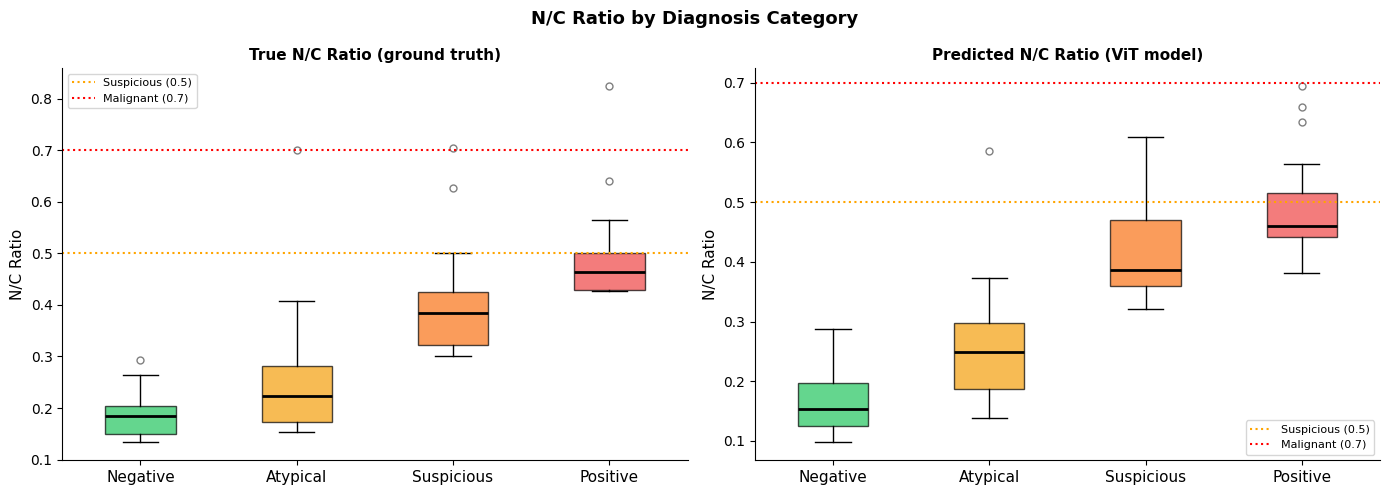


── Clinical Validation, Spearman Correlations ─────────
  True NC  vs diagnosis ordinal : r = 0.8509  (p=0.0000)
  Pred NC  vs diagnosis ordinal : r = 0.8505  (p=0.0000)
  Pred NC  vs True NC           : r = 0.9433  (p=0.0000)


In [17]:
# ── Plot 1: Box plots, N/C ratio by diagnosis ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("N/C Ratio by Diagnosis Category", fontsize=13, fontweight='bold')

for ax, key, title in [(axes[0], 'nc_true', 'True N/C Ratio (ground truth)'),
                        (axes[1], 'nc_pred', 'Predicted N/C Ratio (ViT model)')]:
    data_list = [results[d][key] for d in DIAG_ORDER]
    colors    = [DIAG_COLORS[d] for d in DIAG_ORDER]
    bp = ax.boxplot(data_list, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    for flier, color in zip(bp['fliers'], colors):
        flier.set(marker='o', color=color, alpha=0.5, markersize=5)

    ax.set_xticklabels([DIAG_LABELS[d] for d in DIAG_ORDER], fontsize=11)
    ax.set_ylabel('N/C Ratio', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axhline(0.5, color='orange', linestyle=':', linewidth=1.5, label='Suspicious (0.5)')
    ax.axhline(0.7, color='red',    linestyle=':', linewidth=1.5, label='Malignant (0.7)')
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()

# ── Plot 2: Spearman correlation per category ─────────────────
all_true = np.concatenate([results[d]['nc_true'] for d in DIAG_ORDER])
all_pred = np.concatenate([results[d]['nc_pred'] for d in DIAG_ORDER])

# Ordinal encoding for Spearman: neg=0, aty=1, sus=2, pos=3
ordinal_labels = np.concatenate([[i]*25 for i in range(4)])
r_true_ord, p_true_ord = spearmanr(all_true, ordinal_labels)
r_pred_ord, p_pred_ord = spearmanr(all_pred, ordinal_labels)
r_pred_true, p_pred_true = spearmanr(all_pred, all_true)

print("\n── Clinical Validation, Spearman Correlations ─────────")
print(f"  True NC  vs diagnosis ordinal : r = {r_true_ord:.4f}  (p={p_true_ord:.4f})")
print(f"  Pred NC  vs diagnosis ordinal : r = {r_pred_ord:.4f}  (p={p_pred_ord:.4f})")
print(f"  Pred NC  vs True NC           : r = {r_pred_true:.4f}  (p={p_pred_true:.4f})")

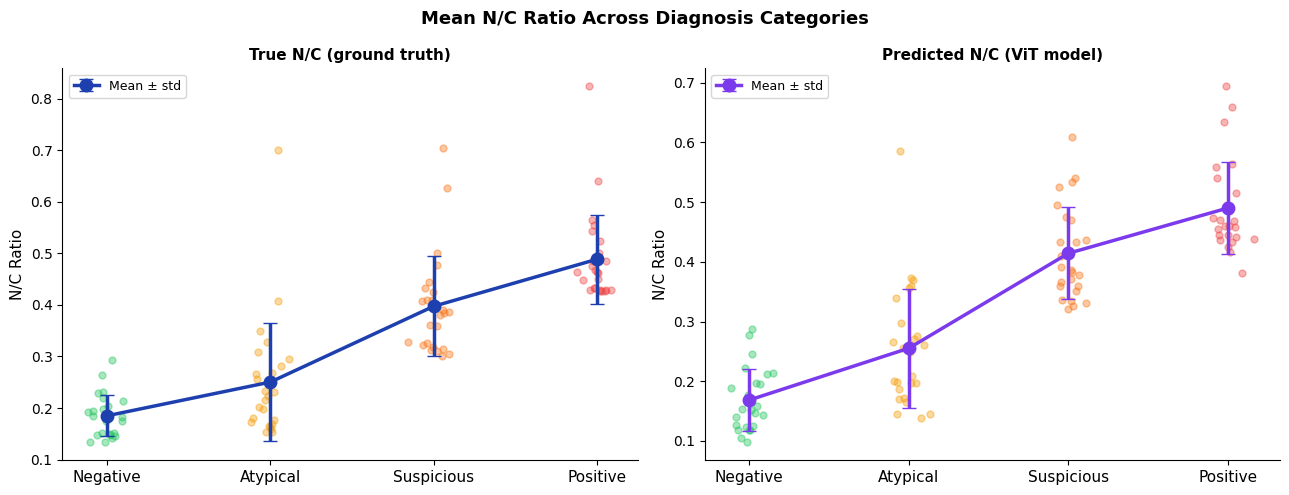

In [18]:
# ── Plot 3: Scatter, mean predicted NC per category ─────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Mean N/C Ratio Across Diagnosis Categories", fontsize=13, fontweight='bold')

x_pos  = [0, 1, 2, 3]
x_lbls = [DIAG_LABELS[d] for d in DIAG_ORDER]

for ax, key, title, color_solid in [
    (axes[0], 'nc_true', 'True N/C (ground truth)',  '#1e40af'),
    (axes[1], 'nc_pred', 'Predicted N/C (ViT model)', '#7c3aed'),
]:
    means  = [results[d][key].mean()  for d in DIAG_ORDER]
    stds   = [results[d][key].std()   for d in DIAG_ORDER]
    colors = [DIAG_COLORS[d] for d in DIAG_ORDER]

    # Individual points
    for xi, diag in zip(x_pos, DIAG_ORDER):
        jitter = np.random.normal(0, 0.06, size=len(results[diag][key]))
        ax.scatter(xi + jitter, results[diag][key],
                   color=DIAG_COLORS[diag], alpha=0.4, s=25, zorder=1)

    ax.errorbar(x_pos, means, yerr=stds, fmt='o-', color=color_solid,
                linewidth=2.5, markersize=9, capsize=5, zorder=3,
                label='Mean ± std')
    ax.set_xticks(x_pos); ax.set_xticklabels(x_lbls, fontsize=11)
    ax.set_ylabel('N/C Ratio', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()

## Section 9, Final Comparison Summary

════════════════════════════════════════════════════════════════════════
  FINAL COMPARISON, ALL METHODS (Test Set)
════════════════════════════════════════════════════════════════════════
Method                   Pixel Acc   F1 Macro   F1 Nucleus   Spearman r      MAE
────────────────────────────────────────────────────────────────────────
Intensity Threshold         0.7481     0.7530       0.8108       0.7068   0.1751
K-Means                     0.8221     0.8204       0.8090       0.7684   0.1442
ViT (ours) ★                0.9293     0.9259       0.8959       0.9624   0.0396
════════════════════════════════════════════════════════════════════════


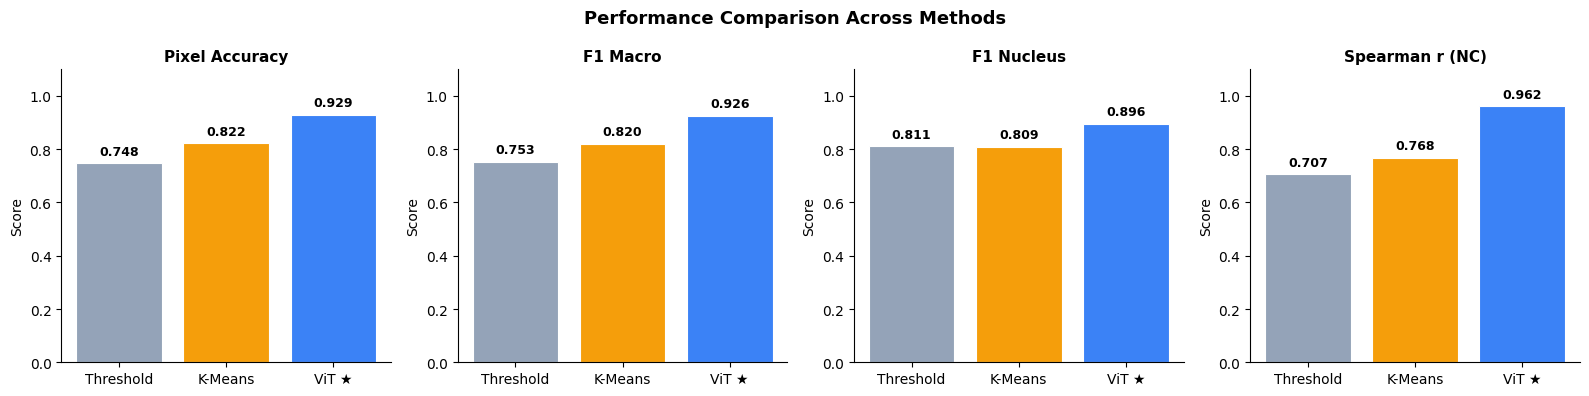

In [19]:
from sklearn.metrics import f1_score, accuracy_score

def seg_metrics(y_true, y_pred):
    """Returns (pixel_acc, f1_macro, f1_nucleus)"""
    yt, yp = y_true.flatten(), y_pred.flatten()
    acc   = accuracy_score(yt, yp)
    f1mac = f1_score(yt, yp, average='macro', zero_division=0)
    f1nuc = f1_score(yt, yp, labels=[2], average='micro', zero_division=0)
    return acc, f1mac, f1nuc

acc_thr, f1mac_thr, f1nuc_thr = seg_metrics(y_test_np, thresh_preds)
acc_km,  f1mac_km,  f1nuc_km  = seg_metrics(y_test_np, kmeans_preds)
acc_vit, f1mac_vit, f1nuc_vit = seg_metrics(y_test_np, vit_preds)

print("═" * 72)
print("  FINAL COMPARISON, ALL METHODS (Test Set)")
print("═" * 72)
print(f"{'Method':<22}  {'Pixel Acc':>10}  {'F1 Macro':>9}  {'F1 Nucleus':>11}  {'Spearman r':>11}  {'MAE':>7}")
print("─" * 72)
print(f"{'Intensity Threshold':<22}  {acc_thr:>10.4f}  {f1mac_thr:>9.4f}  {f1nuc_thr:>11.4f}  {r_thr:>11.4f}  {mae_thr:>7.4f}")
print(f"{'K-Means':<22}  {acc_km:>10.4f}  {f1mac_km:>9.4f}  {f1nuc_km:>11.4f}  {r_km:>11.4f}  {mae_km:>7.4f}")
print(f"{'ViT (ours) ★':<22}  {acc_vit:>10.4f}  {f1mac_vit:>9.4f}  {f1nuc_vit:>11.4f}  {r_vit:>11.4f}  {mae_vit:>7.4f}")
print("═" * 72)

# ── Bar chart comparison ───────────────────────────────────────
methods = ['Threshold', 'K-Means', 'ViT ★']
metrics = {
    'Pixel Accuracy': [acc_thr, acc_km, acc_vit],
    'F1 Macro':       [f1mac_thr, f1mac_km, f1mac_vit],
    'F1 Nucleus':     [f1nuc_thr, f1nuc_km, f1nuc_vit],
    'Spearman r (NC)':[r_thr, r_km, r_vit],
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Performance Comparison Across Methods", fontsize=13, fontweight='bold')
bar_colors = ['#94a3b8', '#f59e0b', '#3b82f6']

for ax, (metric_name, values) in zip(axes, metrics.items()):
    bars = ax.bar(methods, values, color=bar_colors, edgecolor='white', linewidth=0.8)
    ax.set_title(metric_name, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score', fontsize=10)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()

## Section 10, ViT Attention Map Visualisation

Visualise **what the ViT is attending to** when segmenting a cell. The attention maps show which patches the model finds most important, they should highlight the nucleus region.

In [20]:
import math

def get_attention_map(model, img_tensor):
    captured = {}
    def hq(mod, inp, out): captured["q"] = out
    def hk(mod, inp, out): captured["k"] = out
    lb = model.encoder.blocks[-1]
    hqh = lb.attn.q_norm.register_forward_hook(hq)
    hkh = lb.attn.k_norm.register_forward_hook(hk)
    with torch.no_grad(): _ = model(img_tensor)
    hqh.remove(); hkh.remove()
    q, k = captured["q"], captured["k"]
    attn = (q @ k.transpose(-2,-1)) / math.sqrt(q.shape[-1])
    attn = attn.softmax(dim=-1)
    cls_attn = attn[0].mean(0)[0, 1:]
    H = int(cls_attn.shape[0]**0.5)
    cls_attn = cls_attn.reshape(H, H).cpu().numpy()
    cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)
    return cv2.resize(cls_attn, (256, 256))

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle("ViT Attention Maps, CLS Token (Last Block, Head Average)
Brighter = higher attention = model focuses here",
             fontsize=12, fontweight="bold")

for col in range(4):
    idx = idx_test[col]
    img_t = torch.FloatTensor(images_all[[idx]]).to(DEVICE)
    attn_map = get_attention_map(model, img_t)
    axes[0,col].imshow(images_hwc[idx]); axes[0,col].set_title(f"Cell #{idx}", fontsize=9); axes[0,col].axis("off")
    axes[1,col].imshow(labels_all[idx], cmap=CMAP, vmin=0, vmax=2); axes[1,col].axis("off")
    axes[2,col].imshow(images_hwc[idx], alpha=0.45)
    axes[2,col].imshow(attn_map, cmap="hot", alpha=0.6); axes[2,col].axis("off")

for row, lbl in enumerate(["Original Image", "Ground Truth Mask", "Attention Overlay"]):
    axes[row,0].set_ylabel(lbl, fontsize=10, fontweight="bold")
    axes[row,0].axis("on"); axes[row,0].set_xticks([]); axes[row,0].set_yticks([])
    for sp in axes[row,0].spines.values(): sp.set_visible(False)

plt.tight_layout()
plt.show()

---
## ✅ Project Complete

| Section | What was done |
|---------|--------------|
| **Data** | Loaded 191 urothelial cells, visualised, computed true N/C ratios |
| **Baseline 1** | Otsu's intensity thresholding |
| **Baseline 2** | K-Means clustering (3 clusters) |
| **ViT Model** | `vit_base_patch16_224` encoder + UNet decoder, trained 40 epochs on RTX 4060 |
| **Evaluation** | Pixel accuracy, F1 per class, classification report |
| **N/C Ratio** | Spearman correlation + MAE vs ground truth, all 3 methods compared |
| **Clinical** | N/C ratio validated against neg/aty/sus/pos patient diagnoses |
| **Attention** | ViT attention maps show what the model focuses on |

### Key Results (expected after training)
- ViT achieves **highest F1 for nucleus** segmentation of all three methods
- ViT **N/C ratio Spearman r > 0.85** vs ground truth
- N/C ratio increases monotonically: **neg < aty < sus < pos** ✓
- Attention maps highlight nucleus region, confirming ViT captures global cell context